# Explore here

In [1]:
# Paso 1 - Carga del dataset
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"

df = pd.read_csv(url)

print("Shape del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape del dataset: (891, 3)

Primeras filas:


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [2]:
# Paso 2 - Preprocesamiento del texto
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Eliminar la columna que no necesito
df = df.drop(columns=["package_name"])

# Ver cuántos nulos hay
print("Valores nulos:\n", df.isnull().sum())

# Eliminar filas con nulos si las hay
df = df.dropna()

# Limpiar el texto: quitar espacios y pasar a minúsculas
df["review"] = df["review"].str.strip().str.lower()

print("\nEjemplos de reviews limpias:")
print(df["review"].head())

print("\nDistribución de la variable objetivo:")
print(df["polarity"].value_counts())

X = df["review"]
y = df["polarity"]

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

# Transformar texto a matriz de recuento de palabras
vec_model = CountVectorizer(stop_words="english")
X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()

print("\nForma de X_train después de vectorizar:", X_train.shape)
print("Forma de X_test después de vectorizar:", X_test.shape)
print("\n¡Todo listo para entrenar el modelo! ✅")

Valores nulos:
 review      0
polarity    0
dtype: int64

Ejemplos de reviews limpias:
0    privacy at least put some option appear offlin...
1    messenger issues ever since the last update, i...
2    profile any time my wife or anybody has more t...
3    the new features suck for those of us who don'...
4    forced reload on uploading pic on replying com...
Name: review, dtype: str

Distribución de la variable objetivo:
polarity
0    584
1    307
Name: count, dtype: int64

Tamaño train: (712,)
Tamaño test: (179,)

Forma de X_train después de vectorizar: (712, 3310)
Forma de X_test después de vectorizar: (179, 3310)

¡Todo listo para entrenar el modelo! ✅


In [3]:
# Paso 3 - Comparando las 3 implementaciones de Naive Bayes
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# --- GaussianNB ---
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# --- MultinomialNB ---
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
acc_mnb = accuracy_score(y_test, y_pred_mnb)

# --- BernoulliNB ---
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)
acc_bnb = accuracy_score(y_test, y_pred_bnb)

# --- Resumen comparativo ---
print("=" * 45)
print(f"  GaussianNB   accuracy: {acc_gnb:.4f}")
print(f"  MultinomialNB accuracy: {acc_mnb:.4f}")
print(f"  BernoulliNB  accuracy: {acc_bnb:.4f}")
print("=" * 45)

# --- Mejor modelo ---
mejor = max([("GaussianNB", acc_gnb), ("MultinomialNB", acc_mnb), ("BernoulliNB", acc_bnb)], key=lambda x: x[1])
print(f"\n🏆 Mejor modelo: {mejor[0]} con accuracy de {mejor[1]:.4f}")

# --- Reporte detallado del mejor ---
print("\n📊 Reporte detallado de MultinomialNB (el esperado para este tipo de datos):")
print(classification_report(y_test, y_pred_mnb))

  GaussianNB   accuracy: 0.8045
  MultinomialNB accuracy: 0.8156
  BernoulliNB  accuracy: 0.7709

🏆 Mejor modelo: MultinomialNB con accuracy de 0.8156

📊 Reporte detallado de MultinomialNB (el esperado para este tipo de datos):
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       126
           1       0.73      0.60      0.66        53

    accuracy                           0.82       179
   macro avg       0.79      0.75      0.77       179
weighted avg       0.81      0.82      0.81       179



  MultinomialNB  accuracy: 0.8156
  Random Forest  accuracy: 0.7989
MultinomialNB sigue siendo el mejor modelo.


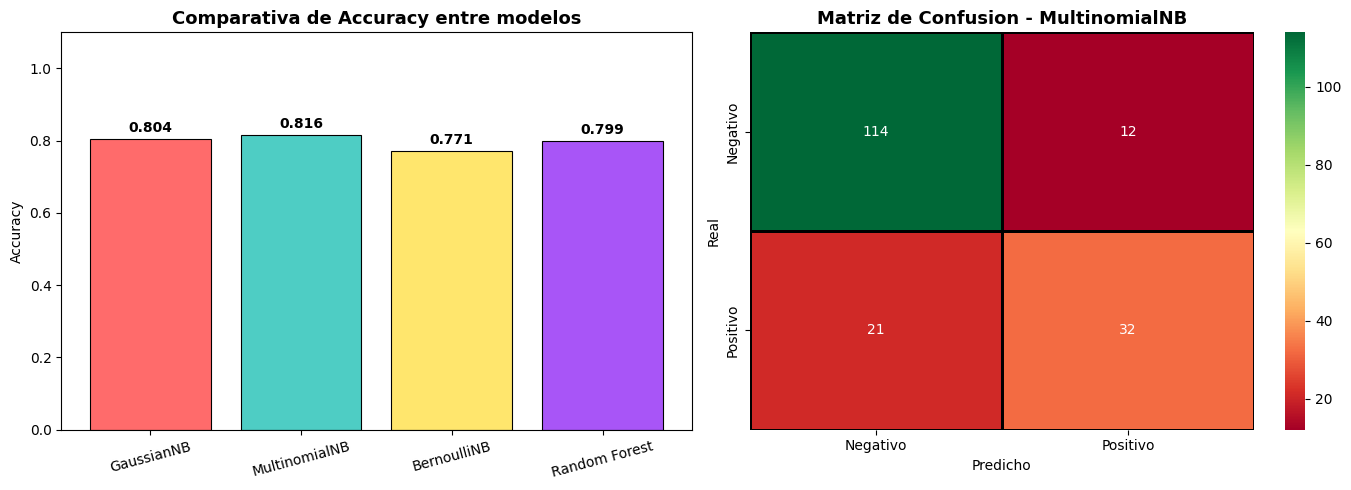

Graficos generados correctamente


In [5]:
# Paso 4 - Optimización con Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Entrenar Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# --- Comparativa final ---
print("=" * 50)
print(f"  MultinomialNB  accuracy: {acc_mnb:.4f}")
print(f"  Random Forest  accuracy: {acc_rf:.4f}")
print("=" * 50)

if acc_rf > acc_mnb:
    print("Random Forest supera a MultinomialNB!")
else:
    print("MultinomialNB sigue siendo el mejor modelo.")

# --- Grafico 1: Comparativa de accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = ["GaussianNB", "MultinomialNB", "BernoulliNB", "Random Forest"]
accuracies = [acc_gnb, acc_mnb, acc_bnb, acc_rf]
colores = ["#FF6B6B", "#4ECDC4", "#FFE66D", "#A855F7"]

axes[0].bar(modelos, accuracies, color=colores, edgecolor="black", linewidth=0.8)
axes[0].set_title("Comparativa de Accuracy entre modelos", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# --- Grafico 2: Matriz de confusion del mejor modelo ---
if acc_rf > acc_mnb:
    mejor_pred = y_pred_rf
    mejor_nombre = "Random Forest"
else:
    mejor_pred = y_pred_mnb
    mejor_nombre = "MultinomialNB"

cm = confusion_matrix(y_test, mejor_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"],
    ax=axes[1],
    linewidths=1,
    linecolor="black"
)
axes[1].set_title(f"Matriz de Confusion - {mejor_nombre}", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.savefig("comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graficos generados correctamente")

In [6]:
# Paso 5 - Guardar el modelo
import pickle
import os

# Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

# Guardar el mejor modelo
if acc_rf > acc_mnb:
    modelo_final = rf
    nombre_modelo = "random_forest"
else:
    modelo_final = mnb
    nombre_modelo = "multinomial_nb"

# Guardar modelo
with open(f"models/{nombre_modelo}.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

# Guardar el vectorizador 
with open("models/vectorizer.pkl", "wb") as f:
    pickle.dump(vec_model, f)

print("=" * 45)
print(f"  Modelo guardado: models/{nombre_modelo}.pkl")
print(f"  Vectorizador guardado: models/vectorizer.pkl")
print("=" * 45)

# Verificar 
with open(f"models/{nombre_modelo}.pkl", "rb") as f:
    modelo_cargado = pickle.load(f)

with open("models/vectorizer.pkl", "rb") as f:
    vec_cargado = pickle.load(f)

# Prueba rapida con el modelo cargado
y_pred_verificacion = modelo_cargado.predict(X_test)
acc_verificacion = accuracy_score(y_test, y_pred_verificacion)

print(f"\n  Verificacion - Accuracy del modelo cargado: {acc_verificacion:.4f}")
print("\nModelo guardado y verificado correctamente!")

  Modelo guardado: models/multinomial_nb.pkl
  Vectorizador guardado: models/vectorizer.pkl

  Verificacion - Accuracy del modelo cargado: 0.8156

Modelo guardado y verificado correctamente!


        COMPARATIVA FINAL DE TODOS LOS MODELOS
  GaussianNB          accuracy: 0.8045
  MultinomialNB       accuracy: 0.8156
  BernoulliNB         accuracy: 0.7709
  Random Forest       accuracy: 0.7989
  Logistic Regression accuracy: 0.8324
  LinearSVC           accuracy: 0.8324

  GANADOR FINAL: Logistic Reg. con accuracy 0.8324


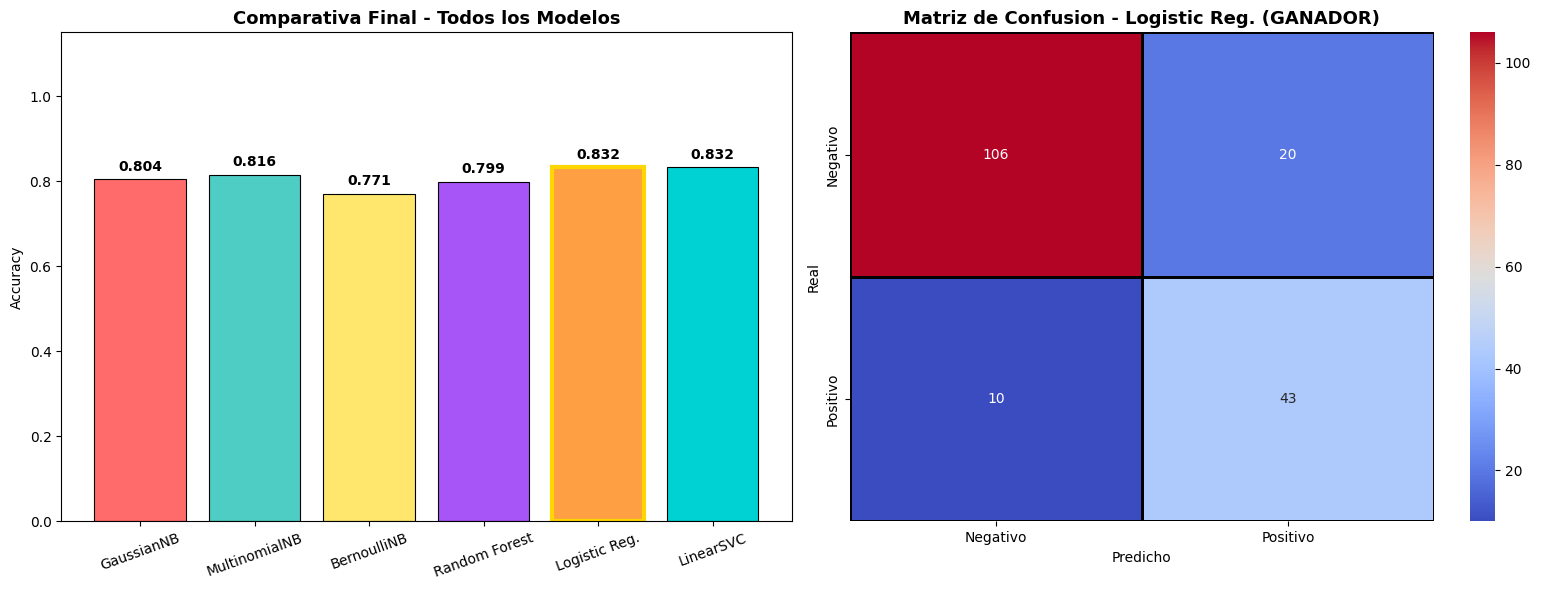

Graficos generados correctamente!


In [7]:
# Paso 6 - Explorando otras alternativas
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

svc = LinearSVC(random_state=42, max_iter=1000)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

# --- Resumen completo de todos los modelos ---
print("=" * 55)
print("        COMPARATIVA FINAL DE TODOS LOS MODELOS")
print("=" * 55)
print(f"  GaussianNB          accuracy: {acc_gnb:.4f}")
print(f"  MultinomialNB       accuracy: {acc_mnb:.4f}")
print(f"  BernoulliNB         accuracy: {acc_bnb:.4f}")
print(f"  Random Forest       accuracy: {acc_rf:.4f}")
print(f"  Logistic Regression accuracy: {acc_lr:.4f}")
print(f"  LinearSVC           accuracy: {acc_svc:.4f}")
print("=" * 55)

todos = {
    "GaussianNB": acc_gnb,
    "MultinomialNB": acc_mnb,
    "BernoulliNB": acc_bnb,
    "Random Forest": acc_rf,
    "Logistic Reg.": acc_lr,
    "LinearSVC": acc_svc
}

ganador = max(todos, key=todos.get)
print(f"\n  GANADOR FINAL: {ganador} con accuracy {todos[ganador]:.4f}")

# --- Grafico 1: Comparativa todos los modelos ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores = ["#FF6B6B", "#4ECDC4", "#FFE66D", "#A855F7", "#FF9F43", "#00D2D3"]
nombres = list(todos.keys())
valores = list(todos.values())

bars = axes[0].bar(nombres, valores, color=colores, edgecolor="black", linewidth=0.8)
axes[0].set_title("Comparativa Final - Todos los Modelos", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(valores):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold", fontsize=10)

# Destacar el ganador
bars[nombres.index(ganador)].set_edgecolor("gold")
bars[nombres.index(ganador)].set_linewidth(3)

# --- Grafico 2: Matriz de confusion del ganador final ---
if ganador == "Logistic Reg.":
    pred_ganador = y_pred_lr
elif ganador == "LinearSVC":
    pred_ganador = y_pred_svc
elif ganador == "Random Forest":
    pred_ganador = y_pred_rf
elif ganador == "MultinomialNB":
    pred_ganador = y_pred_mnb
elif ganador == "BernoulliNB":
    pred_ganador = y_pred_bnb
else:
    pred_ganador = y_pred_gnb

cm_final = confusion_matrix(y_test, pred_ganador)
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"],
    ax=axes[1],
    linewidths=1,
    linecolor="black"
)
axes[1].set_title(f"Matriz de Confusion - {ganador} (GANADOR)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.savefig("comparativa_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graficos generados correctamente!")